This notebook is to understand the difference between zfit's native unextended vs extended crystal ball function and to compare it with the source code and make a 'hand-made' CB function 

In [1]:
import tensorflow as tf
import zfit
import matplotlib.pyplot as plt
import numpy as np
import zfit.z.numpy as znp

/opt/anaconda3/envs/m2_req/lib/python3.10/site-packages/zfit/__init__.py:59: UserWarning: TensorFlow warnings are by default suppressed by zfit. In order to show them, set the environment variable ZFIT_DISABLE_TF_WARNINGS=0. In order to suppress the TensorFlow warnings AND this warning, set ZFIT_DISABLE_TF_WARNINGS=1.
  warnings.warn(


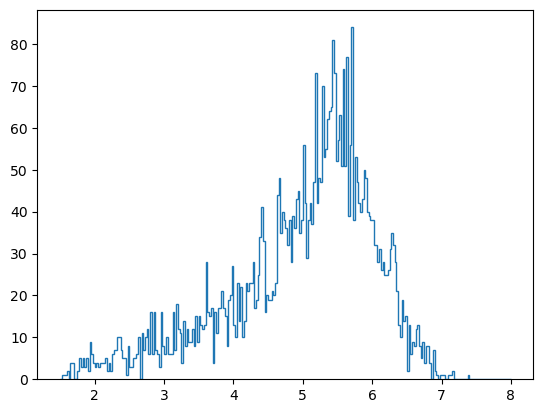

In [3]:
data = zfit.Data.from_root("mu2e_caloSimu_crySpec867.root", "specTree", ["spec", "ratio", "ntrig", "stim", "time", "tErg"]) #importing data from root file
energy_unbinned = data["spec"] #crystal spec is the raw energy values
bin_count = 260 #trivially set depending on what we want the y axis to represent (x evts/kev)
energy_binned, bin_location, patches = plt.hist(energy_unbinned,bins=bin_count,histtype='step',range=(1.5,8)) #binning energy values and creating an x array of bin location
bin_centers =  (bin_location[1:] + bin_location[:-1])/2
cryspec = zfit.Space(['x'], limits=(1.5,8)) #obs range
lower, upper = cryspec.limits
x_range= cryspec.area() 
scale = (len(energy_unbinned)/bin_count)*x_range #the pdfs are normalised to =1 so must apply scaling factor

#### Native Zfit CB

In [14]:
#extended fit
ergElec = 0.511 
A = zfit.Parameter ("A constant", 0.0169, 0.0149, 0.0189);
B = zfit.Parameter ("B constant", 0.01, 0.005, 0.04);
fcbalpha = zfit.Parameter("fcbalpha", 2.5, 0.05, 20.0); #alpha
fcbndeg = zfit.Parameter ("fcbndeg", 10); 
fullPeak = zfit.Parameter( "full peak", 6, 5.6, 6.2); 
fullRes = np.sqrt(pow(A/pow((fullPeak/1000),0.25),2)) + (B)**2 + (0.15/fullPeak)**2 #fractional resolution
fullWidth = zfit.Parameter( "width of the full peak", 0.4); 
EvnFull = zfit.Parameter("No. of Events in full peak", 400);
fullErg = zfit.pdf.CrystalBall(obs=cryspec, mu=fullPeak, sigma=fullWidth, alpha=fcbalpha, n=fcbndeg, extended=EvnFull)
y_plot_full = fullErg.pdf(bin_centers,norm_range=cryspec)

#unextended fit
A_unext = zfit.Parameter ("A constant for unextended fit", 0.03, 0.0149, 0.05);
B_unext = zfit.Parameter ("B constant for unextended fit", 0.03, 0.005, 0.04);
fcbalpha_unext = zfit.Parameter("fcbalpha for unextended fit", 2.5, 0.05, 20.0); #alpha
fcbndeg_unext = zfit.Parameter ("fcbndeg for unextended fit", 10); #n degrees
fullPeak_unext = zfit.Parameter( "full peak for unextended fit", 6, 5.6, 6.2); 
fullRes_unext = np.sqrt(pow(A_unext/pow((fullPeak_unext/1000),0.25),2)) + (B_unext)**2 + (0.15/fullPeak_unext)**2 
fullWidth_unext = zfit.Parameter( "width of the full peak for unextended fit", 0.4 );

fullErg_unext = zfit.pdf.CrystalBall(obs=cryspec, mu=fullPeak_unext, sigma=fullWidth_unext, alpha=fcbalpha_unext, n=fcbndeg_unext)

y_plot_full_unext = fullErg_unext.pdf(bin_centers,norm_range=cryspec)

#### Hand-made Crystal Ball func

In [15]:
from zfit.core.basepdf import BasePDF
from zfit.core.serialmixin import SerializableMixin
from zfit.util import ztyping
from zfit.util.ztyping import ExtendedInputType, NormInputType
from zfit.core.space import ANY_LOWER, ANY_UPPER, Space, supports


A_const = zfit.Parameter ("A constant for created fit", 0.0169, 0.0149, 0.0189);
B_const = zfit.Parameter ("B constant for created fit", 0.01, 0.005, 0.04);
alpha = zfit.Parameter("alpha", 2.5, 0.05, 20.0);
n = zfit.Parameter ("n", 10);
mu = zfit.Parameter( "mu", 6, 5.6, 6.2);
fracRes = np.sqrt(pow(A_const/pow((mu/1000),0.25),2)) + (B_const)**2 + (0.15/mu)**2 #fractional resolution
sigma=zfit.Parameter("sigma of the full peak", 0.4)
fraction = zfit.Parameter("Fraction of peak", 400);


In [16]:
def _powerlaw(x, a, k):
    return a * znp.power(x, k)


class zfitCB(zfit.pdf.ZPDF):
    _N_OBS = 1
    _PARAMS = ['alpha', 'n' ,'mu', 'sigma']


    def _unnormalized_pdf(self,x):
        x = zfit.z.unstack_x(x)
        alpha = self.params['alpha']
        n = self.params['n']
        mu = self.params['mu']
        sigma = self.params['sigma']
        t = (x - mu) / sigma * tf.sign(alpha)
        abs_alpha = znp.abs(alpha)
        a = znp.power((n / abs_alpha), n) * znp.exp(-0.5 * znp.square(alpha))
        b = (n / abs_alpha) - abs_alpha
        cond = tf.less(t, -abs_alpha)
        func = zfit.z.zextension.safe_where(
            cond,
            lambda t: _powerlaw(b - t, a, -n),
            lambda t: znp.exp(-0.5 * znp.square(t)),
            values=t,
            value_safer=lambda t: znp.ones_like(t) * (b - 2),
            )
        return znp.maximum(func, znp.zeros_like(func))

CBfunc = zfitCB(obs=cryspec,mu=mu,alpha=alpha,n=n,sigma=sigma)
y_plot_CB = CBfunc.pdf(bin_centers,norm_range=cryspec)


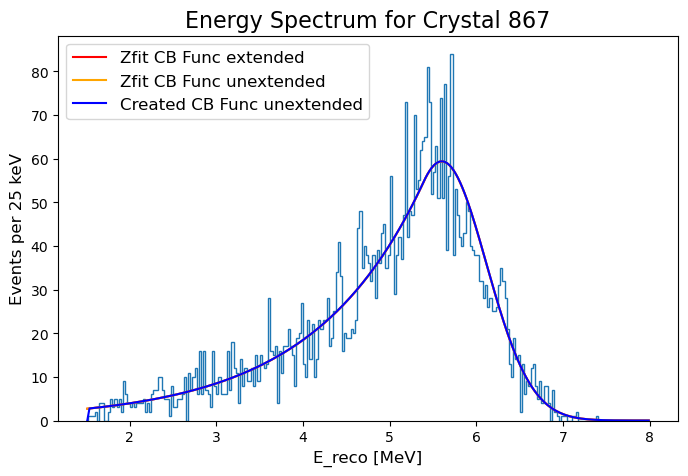

In [21]:
fig, ax = plt.subplots(1,1,figsize=(8,5))
ax.hist(energy_unbinned,bins=bin_count,histtype='step',range=(1.5,8))

plt.plot(bin_centers, y_plot_full*scale, color="red", label='Zfit CB Func extended')
plt.plot(bin_centers, y_plot_full_unext*scale, color="orange", label='Zfit CB Func unextended')
plt.plot(bin_centers, y_plot_CB*scale, color="blue",label='Created CB Func unextended')

plt.title("Energy Spectrum for Crystal 867", fontsize=16)
plt.ylabel('Events per 25 keV',fontsize=12)
plt.xlabel('E_reco [MeV]',fontsize=12)
leg = plt.legend(fontsize=12);

In [18]:
nll_native = zfit.loss.ExtendedUnbinnedNLL(model=fullErg, data=energy_unbinned)
nll_native_unext = zfit.loss.UnbinnedNLL(model=fullErg_unext, data=energy_unbinned)
nll_manual = zfit.loss.UnbinnedNLL(model=CBfunc, data=energy_unbinned) #currently this is not extended 
#nll_manual_combined = zfit.loss.UnbinnedNLL(model=combinedCB, data=energy_unbinned) #currently this is not extended 

minimizer = zfit.minimize.Minuit()

result_1 = minimizer.minimize(nll_native, params=[A, B, fcbalpha,fcbndeg,fullPeak,EvnFull,fullWidth]) #add fraction
result_1_unext = minimizer.minimize(nll_native_unext, params=[A_unext,B_unext,fcbalpha_unext,fcbndeg_unext,fullPeak_unext,fullWidth_unext])
result_2 = minimizer.minimize(nll_manual, params=[A_const,B_const,alpha,n,mu,sigma,fraction])

param_hesse = result_1.hesse()
param_hesse1_unext = result_1_unext.hesse()
param_hesse2 = result_2.hesse()

In [19]:
y_plot_full = fullErg.pdf(bin_centers,norm_range=cryspec)
y_plot_full_unext = fullErg_unext.pdf(bin_centers,norm_range=cryspec)
y_plot_CB = CBfunc.pdf(bin_centers)
#y_plot_CB1 = CBfunc1.pdf(bin_centers)
#y_plot_combined = combinedCB.pdf(bin_centers,norm_range=cryspec)


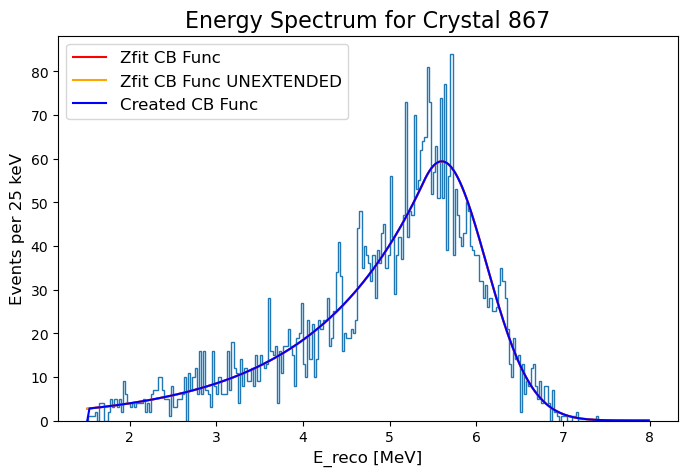

In [20]:
fig, ax = plt.subplots(1,1,figsize=(8,5))
ax.hist(energy_unbinned,bins=bin_count,histtype='step',range=(1.5,8))

plt.plot(bin_centers, y_plot_full*scale, color="red", label='Zfit CB Func')
plt.plot(bin_centers, y_plot_full_unext*scale, color="orange", label='Zfit CB Func UNEXTENDED')
plt.plot(bin_centers, y_plot_CB*scale, color="blue",label='Created CB Func')

plt.title("Energy Spectrum for Crystal 867", fontsize=16)
plt.ylabel('Events per 25 keV',fontsize=12)
plt.xlabel('E_reco [MeV]',fontsize=12)
leg = plt.legend(fontsize=12);

Conclusion: all versions behave the same-- there is no unexpected behavior caused by the extended fit